In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.cm as cm
from matplotlib.patches import Rectangle
from ipywidgets import interact, widgets
import xarray as xr
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')
import cartopy.crs as ccrs
OMBraw = xr.open_mfdataset('/home/maltem/work/python/data/SvalMIZ2024/cruise/2024_KVS_deployment.nc')
OMBtemp = xr.open_mfdataset('/home/maltem/work/python/data/SvalMIZ2024/colocatedFiles/dataset_temp_full.nc')


/home/maltem/.local/lib/python3.10/site-packages/pandas/core/arrays/masked.py:62: UserWarning: Pandas requires version '1.3.4' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (


In [2]:
from TrajectoryEvaluationTemp import StatisticalEvaluation

In [4]:
buoyno = [25]
startdate = datetime.strptime('2024-04-07 00:00:00','%Y-%m-%d %H:%M:%S')
enddate   = datetime.strptime('2024-04-22 00:00:00','%Y-%m-%d %H:%M:%S')
ifiletemp     = '/home/maltem/work/python/data/SvalMIZ2024/colocatedFiles/dataset_temp_full.nc'
ifiledrift    = '/home/maltem/work/python/data/SvalMIZ2024/colocatedFiles/dataset_trajectories_full.nc'

#s1 = StatisticalEvaluation(buoyno,'MET-AROMEArctic',startdate,enddate,[1,1],ifiledrift,ifiletemp)
s1 = StatisticalEvaluation(buoyno,'ECMWF-AIFS',startdate,enddate,[1,1],ifiledrift,ifiletemp)
s1.info()
s1.flag_values(rad_threshold=100)

Statistical evaluation of 1 buoys
Use of model:  ECMWF-AIFS


In [13]:
OMBtemp

<xarray.Dataset>
Dimensions:                      (tr_nr: 33, time_ds: 2929, model: 7, lt_int: 8)
Coordinates:
  * tr_nr                        (tr_nr) int64 1 2 3 4 6 7 ... 29 30 31 32 34 35
  * time_ds                      (time_ds) datetime64[ns] 2024-04-01 ... 2024...
  * model                        (model) object 'MET-AROMEArctic' ... 'MF-ARP...
  * lt_int                       (lt_int) object ']0_12]' ... ']84_96]'
Data variables: (12/31)
    lat_obs                      (tr_nr, time_ds) float64 dask.array<chunksize=(33, 2929), meta=np.ndarray>
    lon_obs                      (tr_nr, time_ds) float64 dask.array<chunksize=(33, 2929), meta=np.ndarray>
    temp_1m_calibrated           (tr_nr, time_ds) float64 dask.array<chunksize=(33, 2929), meta=np.ndarray>
    temp_10cm_calibrated         (tr_nr, time_ds) float64 dask.array<chunksize=(33, 2929), meta=np.ndarray>
    temp_snowsurface_calibrated  (tr_nr, time_ds) float64 dask.array<chunksize=(33, 2929), meta=np.ndarray>
    temp_snowice_calibrated      (tr_nr, time_ds) float64 dask.array<chunksize=(33, 2929), meta=np.ndarray>
    ...                           ...
    sldr                         (model, lt_int, tr_nr, time_ds) float64 dask.array<chunksize=(7, 8, 33, 2929), meta=np.ndarray>
    slur                         (model, lt_int, tr_nr, time_ds) float64 dask.array<chunksize=(7, 8, 33, 2929), meta=np.ndarray>
    ssdr                         (model, lt_int, tr_nr, time_ds) float64 dask.array<chunksize=(7, 8, 33, 2929), meta=np.ndarray>
    ssur                         (model, lt_int, tr_nr, time_ds) float64 dask.array<chunksize=(7, 8, 33, 2929), meta=np.ndarray>
    temp_flag_1m                 (tr_nr, time_ds) float64 dask.array<chunksize=(33, 2929), meta=np.ndarray>
    temp_flag_cons               (tr_nr, time_ds) float64 dask.array<chunksize=(33, 2929), meta=np.ndarray>

In [14]:
def plot_buoy_data(time_index, model_name, lead_time_index):
    # Set up the figure and Cartopy map
    fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.PlateCarree()})
    
    # Define the extent to cover the area around Svalbard
    ax.set_extent([0, 25, 77, 83], crs=ccrs.PlateCarree())
    ax.coastlines(resolution='10m', color='black', linewidth=1)
    
    # Get the model index by matching the model name
    model_index = np.where(OMBtemp.model.values == model_name)[0][0]  # Find index of selected model
    
    # Extract the model and observation data
    model_data       = OMBtemp.T2M               [model_index, lead_time_index, : , time_index].values
    observation_data = OMBtemp.temp_1m_calibrated[buoyno, time_index].values
    
    # Plot model data at buoy positions
    scatter_model = ax.scatter(OMBtemp.lon_obs, OMBtemp.lat_obs, c=model_data, cmap='viridis', s=100, label='Model Data', transform=ccrs.PlateCarree())
    
    # Plot observation data at buoy positions
    #scatter_observation = ax.scatter(OMBtemp.lon_obs, OMBtemp.lat_obs, c=observation_data, cmap='coolwarm', s=100, marker='x', label='Observation Data', transform=ccrs.PlateCarree())
    
    # Add color bars
    fig.colorbar(scatter_model, ax=ax, orientation='vertical', label='Model Temperature (°C)')
    fig.colorbar(scatter_observation, ax=ax, orientation='vertical', label='Observation Temperature (°C)')
    
    # Add title
    ax.set_title(f"Buoy Temperatures\nTime: {str(OMBtemp.time_ds.values[time_index])}, Model: {model_name}, Lead Time: {s1.OMBtemp.lt_int[lead_time_index]} hours")
    
    # Show the plot
    plt.show()


In [16]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import ipywidgets as widgets
from ipywidgets import interact

def plot_buoy_data(start_time_index, end_time_index, model_name, lead_time_index):
    # Ensure start_time_index is less than end_time_index
    if start_time_index > end_time_index:
        print("Start time should be less than end time.")
        return
    
    # Set up the figure and Cartopy map
    fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.PlateCarree()})
    
    # Define the extent to cover the area around Svalbard
    ax.set_extent([0, 25, 77, 83], crs=ccrs.PlateCarree())
    ax.coastlines(resolution='10m', color='black', linewidth=1)
    
    # Get the model index by matching the model name
    model_index = np.where(OMBtemp.model.values == model_name)[0][0]  # Find index of selected model
    
    # Extract model and observation data within the selected time range
    model_data = OMBtemp.T2M[model_index, lead_time_index, :, start_time_index:end_time_index+1].values
    observation_data = OMBtemp.temp_1m_calibrated[buoyno, start_time_index:end_time_index+1].values

    # Plot model data at buoy positions (average across the time range for visualization)
    model_data_mean = model_data.mean(axis=-1)  # Take the mean across the time range
    scatter_model = ax.scatter(OMBtemp.lon_obs, OMBtemp.lat_obs, c=model_data_mean, cmap='viridis', s=100, label='Model Data', transform=ccrs.PlateCarree())

    # Plot observation data at buoy positions (average across the time range for visualization)
    observation_data_mean = observation_data.mean(axis=-1)  # Take the mean across the time range
    scatter_observation = ax.scatter(OMBtemp.lon_obs, OMBtemp.lat_obs, c=observation_data_mean, cmap='coolwarm', s=100, marker='x', label='Observation Data', transform=ccrs.PlateCarree())

    # Add color bars
    fig.colorbar(scatter_model, ax=ax, orientation='vertical', label='Model Temperature (°C)')
    fig.colorbar(scatter_observation, ax=ax, orientation='vertical', label='Observation Temperature (°C)')
    
    # Add title
    ax.set_title(f"Buoy Temperatures\nStart Time: {str(OMBtemp.time_ds.values[start_time_index])}, End Time: {str(OMBtemp.time_ds.values[end_time_index])}, Model: {model_name}, Lead Time: {OMBtemp.lt_int[lead_time_index]} hours")
    
    # Show the plot
    plt.show()


Widget Javascript not detected.  It may not be installed or enabled properly. Reconnecting the current kernel may help.


<function __main__.plot_buoy_data(start_time_index, end_time_index, model_name, lead_time_index)>

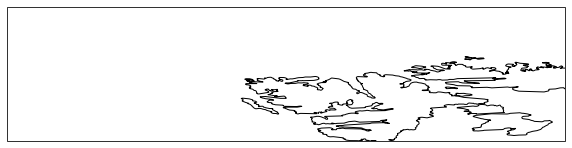

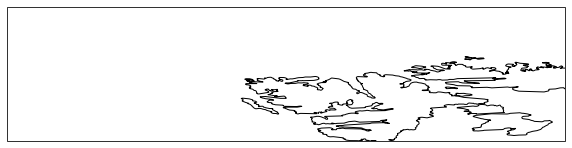

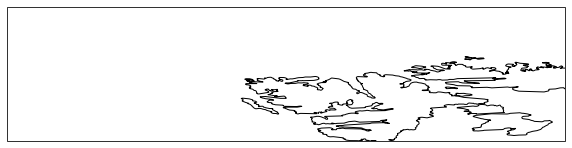

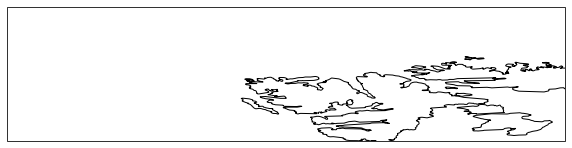

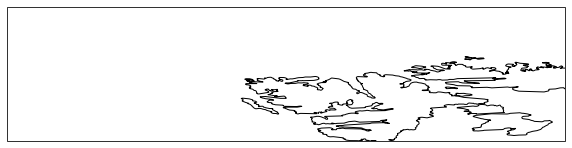

In [17]:
# Create the time range slider widgets (start and end time indices)
start_time_widget = widgets.IntSlider(value=0, min=0, max=len(OMBtemp.time_ds.values) - 1, step=1, description='Start Time:')
end_time_widget = widgets.IntSlider(value=0, min=0, max=len(OMBtemp.time_ds.values) - 1, step=1, description='End Time:')

# Ensure that end time is greater than or equal to start time
widgets.jslink((start_time_widget, 'value'), (end_time_widget, 'min'))  # Set min value of end_time_widget
widgets.jslink((end_time_widget, 'value'), (start_time_widget, 'max'))  # Set max value of start_time_widget

# Extract model names as a list
model_options = OMBtemp.model.values.tolist()

# Create interactive widgets for model and lead-time interval selection
model_widget = widgets.Dropdown(options=model_options, description='Model:')
lead_time_widget = widgets.IntSlider(value=0, min=0, max=4, step=1, description='Lead Time:')

# Use the interact function to update the plot interactively
interact(plot_buoy_data, start_time_index=start_time_widget, end_time_index=end_time_widget, model_name=model_widget, lead_time_index=lead_time_widget)
